# Part 2: Build Your Own GeoAI Pipeline

This notebook turns `src/build_graph.py` into a guided workshop exercise. You will go from a named place to a clustered urban graph representation, then export an interactive web map for inspection.

## What you will produce
- An H3 hexagon grid covering your study area
- Point-of-interest and land-use features for each hexagon
- A walkability graph or a faster contiguity graph
- Learned node embeddings from a Graph Autoencoder (GAE)
- HDBSCAN and K-Means urban clusters
- An interactive HTML map saved to `data/interactive_map.html`

## How to use this notebook
1. Run the cells from top to bottom.
2. At each milestone, check the figure or printed summary before moving on.
3. If your area produces too many hexagons, choose a smaller place or keep the faster contiguity-only option enabled.

## Milestones
- **Milestone 1:** The area boundary and hex grid look correct.
- **Milestone 2:** POIs and land-use features were joined successfully.
- **Milestone 3:** Graph edges were created and look plausible.
- **Milestone 4:** Features and edge weights were scaled correctly.
- **Milestone 5:** GAE training loss decreases over time.
- **Milestone 6:** Clusters appear spatially coherent on the map.
- **Milestone 7:** The interactive HTML map opens with cluster layers.

In [ ]:
from pathlib import Path
import sys
import random

import contextily as ctx
import folium
import geopandas as gpd
import h3
import hdbscan
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
import city2graph as c2g

from IPython.display import display
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely.geometry import Point, Polygon
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, normalize
from torch_geometric.nn import GAE, GATConv

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from poi_and_land_uses import (
    classify_poi,
    compute_land_use_ratios,
    save_unmapped_categories,
    save_unmapped_land_use_categories,
)

DATA_DIR = PROJECT_ROOT / "data"
IMG_DIR = PROJECT_ROOT / "img"
DATA_DIR.mkdir(exist_ok=True)
IMG_DIR.mkdir(exist_ok=True)

CLUSTERING_RESULT_PATH = IMG_DIR / "clustering_result.png"
INTERACTIVE_MAP_PATH = DATA_DIR / "interactive_map.html"
EMBEDDINGS_PATH = DATA_DIR / "homo_with_embeddings.pt"
PLACE_GEOJSON_PATH = DATA_DIR / "place.geojson"
LAND_USE_GEOJSON_PATH = DATA_DIR / "land_use.geojson"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
ox.settings.seed = SEED

plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
sns.set_theme(style="whitegrid")

DARK_BG = "#0f0f0f"
DARK_PANEL = "#161616"
DARK_EDGE = "#333333"
LIGHT_EDGE = "#ffffff"
ATTRIBUTION_COLOR = "#cccccc"
EDGE_CMAP = "RdYlBu"

def add_darkmatter_basemap(ax, crs):
    ctx.add_basemap(
        ax,
        crs=crs.to_string() if hasattr(crs, "to_string") else str(crs),
        source=ctx.providers.CartoDB.DarkMatter,
        alpha=1,
        attribution="",
    )

def style_dark_axes(ax, title=None):
    ax.set_facecolor(DARK_BG)
    if title is not None:
        ax.set_title(title, color="white")
    ax.set_axis_off()

def style_dark_chart(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor(DARK_BG)
    for spine in ax.spines.values():
        spine.set_color(ATTRIBUTION_COLOR)
    ax.tick_params(colors="white")
    if title is not None:
        ax.set_title(title, color="white")
    if xlabel is not None:
        ax.set_xlabel(xlabel, color="white")
    if ylabel is not None:
        ax.set_ylabel(ylabel, color="white")

def build_cluster_color_map(labels, cmap_name="turbo", noise_label=None, noise_color="#333333"):
    unique_labels = sorted(set(labels))
    mapped_labels = [label for label in unique_labels if label != noise_label]
    palette = sns.color_palette(cmap_name, len(mapped_labels)) if mapped_labels else []
    color_map = {
        label: mcolors.to_hex(color)
        for label, color in zip(mapped_labels, palette)
    }
    if noise_label is not None and noise_label in unique_labels:
        color_map[noise_label] = noise_color
    return color_map

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs will be saved under: {DATA_DIR} and {IMG_DIR}")

## Step 0. Choose Your Study Area

Pick a district, borough, or neighbourhood that Nominatim API on OpenSteetMap can resolve clearly.

Use the format `Neighbourhood, City, Country`.

Examples:
- `Camden, London, UK`
- `Shibuya, Tokyo, Japan`

Or, `City, Country` also works if it is not a mega city (e.g., `Tokyo, Japan`).

Examples:
- `Liverpool, UK`
- `Amsterdam, Netherlands`

When generating the hexagons, check the number of hexagons as they would impact the computaton time in the following steps.

Runtime guidance for a first attempt with `H3_RESOLUTION = 9` with `USE_CONTIGUITY_GRAPH_ONLY = False` (chosen later):
- Fewer than 100 hexagons: usually under 1 minute
- Around 200 to 500 hexagons: usually 1 to 3 minutes
- Around 1,000 hexagons: often 5 to 15 minutes
- Several thousand hexagons: potentially 30 minutes or more

**For this workshop, start small and ensure that the overall workflow runs properly first!**

In [2]:
# ← change to your area
AREA_NAME = "Shinjuku, Tokyo, Japan"

# change it to larger one only when the area you chose is too small. 9 is optimal, 10 is fine.
H3_RESOLUTION = 9

## Step 1. Define the Area and Generate H3 Hexagons

This step retrieves the place boundary and fills it with H3 cells.

What to check before moving on:
- The area boundary matches the neighbourhood you intended to analyse.
- The printed hexagon count looks manageable for your machine and workshop time.
- The automatically estimated projected CRS looks reasonable for your region.

In [3]:
boundary_gdf = c2g.get_boundaries(AREA_NAME)
EPSG = boundary_gdf.estimate_utm_crs().to_epsg()

boundary_polygon = boundary_gdf.geometry.union_all()

h3_indices = set()
if boundary_polygon.geom_type == "MultiPolygon":
    for poly in boundary_polygon.geoms:
        geo = {
            "type": "Polygon",
            "coordinates": [list(poly.exterior.coords)],
        }
        h3_indices |= set(h3.geo_to_cells(geo, res=H3_RESOLUTION))
else:
    geo = {
        "type": "Polygon",
        "coordinates": [list(boundary_polygon.exterior.coords)],
    }
    h3_indices = set(h3.geo_to_cells(geo, res=H3_RESOLUTION))

h3_indices = sorted(h3_indices)

if not h3_indices:
    raise ValueError("No H3 cells were generated. Choose a different area name or check the boundary lookup.")

hex_records = []
for h3_id in h3_indices:
    boundary_coords = h3.cell_to_boundary(h3_id)
    polygon = Polygon([(lng, lat) for lat, lng in boundary_coords])
    lat, lng = h3.cell_to_latlng(h3_id)
    hex_records.append({
        "h3_index": h3_id,
        "geometry": Point(lng, lat),
        "hex_polygon": polygon,
    })

hex_gdf = (
    gpd.GeoDataFrame(hex_records, crs="EPSG:4326")
    .set_index("h3_index")
    .to_crs(epsg=EPSG)
)
hex_gdf["hex_polygon"] = gpd.GeoSeries(hex_gdf["hex_polygon"], crs="EPSG:4326").to_crs(epsg=EPSG)

hex_poly_gdf = hex_gdf.set_geometry("hex_polygon")
boundary_projected = boundary_gdf.to_crs(hex_poly_gdf.crs)

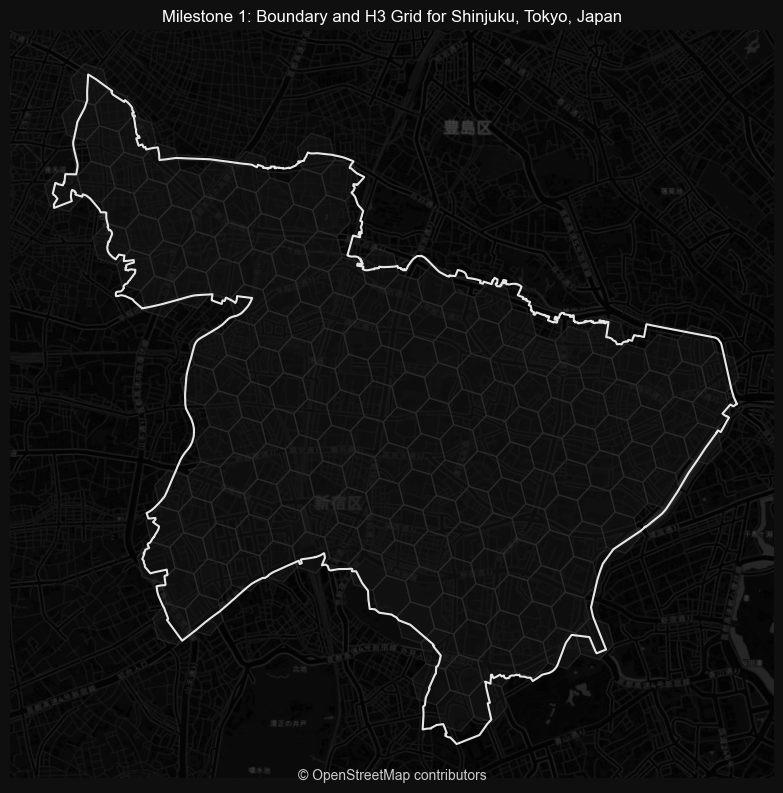

In [4]:
fig, ax = plt.subplots(figsize=(8, 8), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)

boundary_projected.boundary.plot(ax=ax, color=LIGHT_EDGE, linewidth=1.5, alpha=0.9)
hex_poly_gdf.plot(ax=ax, facecolor=DARK_PANEL, edgecolor=DARK_EDGE, linewidth=1.0, alpha=0.55)

add_darkmatter_basemap(ax, hex_poly_gdf.crs)
style_dark_axes(ax, f"Milestone 1: Boundary and H3 Grid for {AREA_NAME}")
fig.text(0.5, 0.02, "© OpenStreetMap contributors", ha="center", fontsize=10, color=ATTRIBUTION_COLOR)
plt.tight_layout()
plt.show()

In [5]:
print(f"Number of H3 hexagons: {len(h3_indices)}")

Number of H3 hexagons: 191


In [6]:
display(hex_gdf.head())

,geometry,hex_polygon
h3_index,,
892f5a32907ffff,POINT (386315.438 3951977.966),"POLYGON ((386494.381 3951923.285, 386445.679 3..."
892f5a32923ffff,POINT (385778.634 3952142.001),"POLYGON ((385957.564 3952087.324, 385908.865 3..."
892f5a32927ffff,POINT (385469.483 3952056.202),"POLYGON ((385648.405 3952001.525, 385599.708 3..."
892f5a32933ffff,POINT (386006.264 3951892.167),"POLYGON ((386185.199 3951837.487, 386136.499 3..."
892f5a32937ffff,POINT (385697.103 3951806.373),"POLYGON ((385876.031 3951751.692, 385827.332 3..."


## Step 2. Fetch POIs and Land Use from Overture Maps

Now we enrich each hexagon with urban context.

This step does four things:
1. Downloads Overture place and land-use layers for the selected boundary.
2. Classifies POIs into broader workshop-friendly categories.
3. Counts how many POIs fall inside each hexagon.
4. Computes the share of each hexagon occupied by simplified land-use classes.

What to check before moving on:
- The fetch completes successfully and saves `place.geojson` and `land_use.geojson`.
- The land-use ratio columns look sensible and stay between 0 and 1 before scaling.
- The `poi_count` column is populated, even if many cells contain zero.

In [ ]:
overture_data = c2g.load_overture_data(
    area=boundary_polygon,
    types=["place", "land_use"],
    output_dir=str(DATA_DIR),
    save_to_file=True,
    return_data=True,
)
print(f"Saved place data to '{PLACE_GEOJSON_PATH}'")
print(f"Saved land use data to '{LAND_USE_GEOJSON_PATH}'")

In [8]:
pois_gdf = overture_data["place"].to_crs(epsg=EPSG).copy()
pois_gdf["categories"] = pois_gdf.get("categories", None)
pois_gdf["functional_class"] = pois_gdf["categories"].apply(classify_poi)
save_unmapped_categories()
pois_gdf["geometry"] = pois_gdf.geometry.centroid

hex_poly_gdf = hex_gdf.set_geometry("hex_polygon")
joined_pois = gpd.sjoin(pois_gdf, hex_poly_gdf, how="inner", predicate="within")

poi_counts = joined_pois.groupby("h3_index").size().rename("poi_count")
hex_gdf["poi_count"] = hex_gdf.index.map(poi_counts).fillna(0).astype(int)

if "functional_class" in joined_pois.columns:
    poi_counts_by_class = joined_pois.groupby(["h3_index", "functional_class"]).size().unstack(fill_value=0).reindex(hex_gdf.index, fill_value=0).astype(int)

    existing_poi_class_cols = hex_gdf.columns.intersection(poi_counts_by_class.columns)
    if len(existing_poi_class_cols) > 0:
        hex_gdf = hex_gdf.drop(columns=existing_poi_class_cols)

    hex_gdf[poi_counts_by_class.columns] = poi_counts_by_class
else:
    poi_counts_by_class = pd.DataFrame(index=hex_gdf.index)

landuse_gdf = overture_data["land_use"].to_crs(epsg=EPSG).copy()
if "subtype" in landuse_gdf.columns and "class" in landuse_gdf.columns:
    landuse_gdf["landuse_category"] = landuse_gdf["subtype"].fillna(landuse_gdf["class"])
elif "subtype" in landuse_gdf.columns:
    landuse_gdf["landuse_category"] = landuse_gdf["subtype"]
elif "class" in landuse_gdf.columns:
    landuse_gdf["landuse_category"] = landuse_gdf["class"]
else:
    landuse_gdf["landuse_category"] = "unknown"

existing_landuse_ratio_cols = [
    column for column in hex_gdf.columns
    if isinstance(column, str) and column.startswith("land_use_") and column.endswith("_ratio")
]
if existing_landuse_ratio_cols:
    hex_gdf = hex_gdf.drop(columns=existing_landuse_ratio_cols)

landuse_ratios, dominant_landuse = compute_land_use_ratios(hex_gdf, landuse_gdf)
save_unmapped_land_use_categories()
hex_gdf["landuse"] = dominant_landuse
if not landuse_ratios.empty:
    hex_gdf[landuse_ratios.columns] = landuse_ratios

landuse_ratio_cols = list(landuse_ratios.columns)

In [9]:
preview_cols = ["poi_count", "landuse"]
preview_cols += list(poi_counts_by_class.columns[:3])
preview_cols += list(landuse_ratio_cols[:3])
display(hex_gdf[preview_cols])

,poi_count,landuse,arts_culture,automotive_facility,consumer_service,land_use_agricultural_ratio,land_use_developed_ratio,land_use_green_space_ratio
h3_index,,,,,,,,
892f5a32907ffff,98,public_services,0,3,4,0.000000,0.000000,0.011027
892f5a32923ffff,84,public_services,2,1,4,0.000000,0.000000,0.022261
892f5a32927ffff,91,public_services,3,1,9,0.000000,0.000000,0.005854
892f5a32933ffff,95,residential,0,1,6,0.000000,0.003016,0.006844
892f5a32937ffff,334,green_space,13,0,30,0.000000,0.000000,0.041511
...,...,...,...,...,...,...,...,...
892f5aadb73ffff,40,green_space,4,0,1,0.014545,0.000000,0.372405
892f5aadb77ffff,5,green_space,1,0,0,0.013758,0.000000,0.708039
892f5aadb7bffff,196,green_space,10,4,19,0.000176,0.000000,0.050448


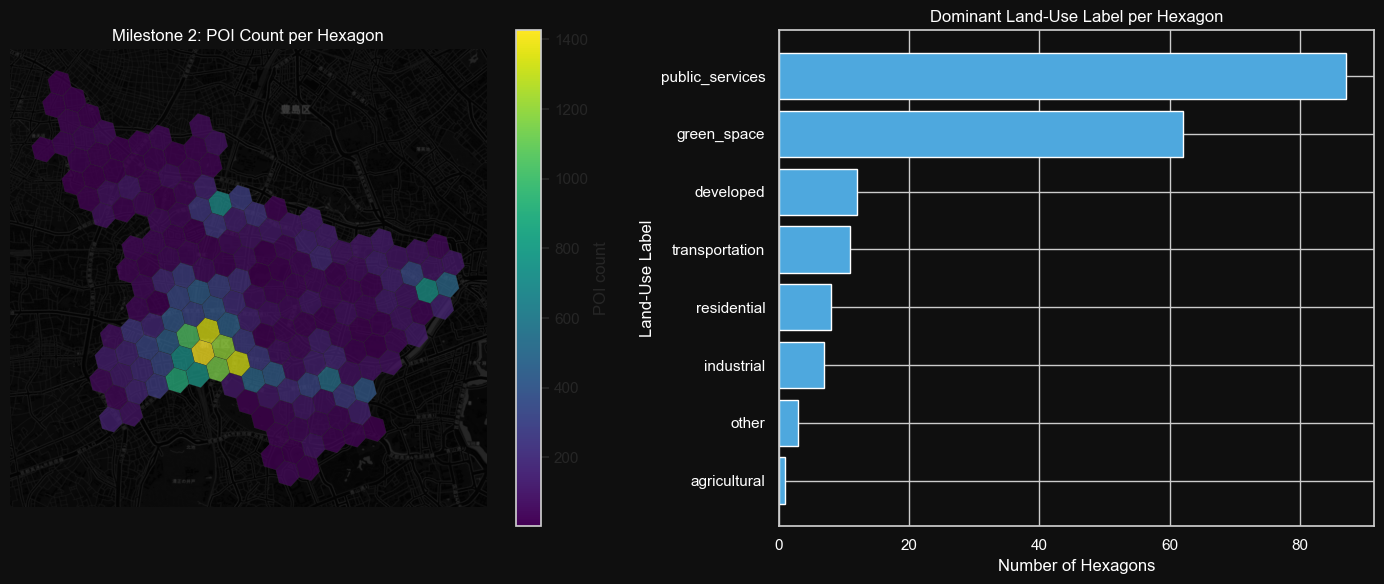

Total POIs joined to hexagons: 30157
Distinct dominant land-use labels: 8
Mean classified land-use coverage ratio per hexagon: 0.18


In [10]:
landuse_counts = hex_gdf["landuse"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=DARK_BG)
for axis in axes:
    axis.set_facecolor(DARK_BG)

hex_poly_gdf = hex_gdf.set_geometry("hex_polygon")
hex_poly_gdf.plot(
    column="poi_count",
    ax=axes[0],
    cmap="viridis",
    edgecolor=DARK_EDGE,
    linewidth=0.2,
    alpha=0.75,
    legend=True,
    legend_kwds={"label": "POI count"},
)
add_darkmatter_basemap(axes[0], hex_poly_gdf.crs)
style_dark_axes(axes[0], "Milestone 2: POI Count per Hexagon")

axes[1].barh(landuse_counts.index[::-1], landuse_counts.values[::-1], color="#4ea8de")
style_dark_chart(
    axes[1],
    "Dominant Land-Use Label per Hexagon",
    "Number of Hexagons",
    "Land-Use Label",
)

plt.tight_layout()
plt.show()

print(f"Total POIs joined to hexagons: {len(joined_pois)}")
print(f"Distinct dominant land-use labels: {hex_gdf['landuse'].nunique()}")
if landuse_ratio_cols:
    mean_landuse_coverage = hex_gdf[landuse_ratio_cols].sum(axis=1).mean()
    print(f"Mean classified land-use coverage ratio per hexagon: {mean_landuse_coverage:.2f}")

## Step 3. Build the Graph Edges

You now need relationships between hexagons. This notebook supports two modes:

- **Fast mode (`USE_CONTIGUITY_GRAPH_ONLY = True`)**: connect neighbouring H3 cells directly.
- **Full mode (`USE_CONTIGUITY_GRAPH_ONLY = False`)**: build a street network, connect each hexagon to it, and compute 15-minute walk metapaths.

For the workshop, the fast mode is recommended.

What to check before moving on:
- The edge count is non-zero.
- The map looks connected rather than empty or completely saturated.
- Travel time values are present on the edges.

In [11]:
# Set your preference for the next steps here:
USE_CONTIGUITY_GRAPH_ONLY = False

# Fixed parameters but if you want, you can change them here
WALKING_SPEED_MPS = 4.8 / 3.6
THRESHOLD_SEC = 15 * 60.0

In [12]:
if USE_CONTIGUITY_GRAPH_ONLY:
    print("USE_CONTIGUITY_GRAPH_ONLY=True: using contiguity graph.")
    _, walk_edges = c2g.contiguity_graph(
        gdf=hex_gdf.set_geometry("hex_polygon"),
        contiguity="queen",
        distance_metric="euclidean",
    )
    if not walk_edges.empty:
        walk_edges["travel_time_sec"] = walk_edges["weight"] / WALKING_SPEED_MPS
    graph_mode = "contiguity"
else:
    print("Fetching street network from OpenStreetMap...")
    G = ox.graph_from_place(AREA_NAME, network_type="walk")
    street_nodes, street_edges = c2g.nx_to_gdf(G)
    street_nodes = street_nodes.to_crs(epsg=EPSG)
    street_edges = street_edges.to_crs(epsg=EPSG)
    street_edges["travel_time_sec"] = street_edges.length / WALKING_SPEED_MPS

    hetero_nodes = {
        "hex": hex_gdf,
        "street_connector": street_nodes,
    }
    hetero_edges = {
        ("street_connector", "is_connected_to", "street_connector"): street_edges,
    }

    bridge_key = ("hex", "is_nearby", "street_connector")
    _, bridged_edges = c2g.bridge_nodes(
        nodes_dict=hetero_nodes,
        source_node_types=["hex"],
        target_node_types=["street_connector"],
        k=1,
    )
    hetero_edges.update(bridged_edges)
    hetero_edges[bridge_key]["travel_time_sec"] = bridged_edges[bridge_key].length / WALKING_SPEED_MPS

    hetero_nodes, hetero_edges = c2g.add_metapaths_by_weight(
        nodes=hetero_nodes,
        edges=hetero_edges,
        weight="travel_time_sec",
        threshold=THRESHOLD_SEC,
        new_relation_name="15_min_walk",
        endpoint_type="hex",
        edge_types=[
            bridge_key,
            ("street_connector", "is_connected_to", "street_connector"),
        ],
        directed=False,
    )
    walk_edges = hetero_edges[("hex", "15_min_walk", "hex")]
    graph_mode = "street network + 15-minute metapaths"

print(f"Graph mode used: {graph_mode}")
print(f"Hex-to-hex edges: {len(walk_edges)}")
display(walk_edges[["travel_time_sec"]].describe())

Fetching street network from OpenStreetMap...
Graph mode used: street network + 15-minute metapaths
Hex-to-hex edges: 3598


,travel_time_sec
count,3598.000000
mean,630.329860
std,178.045627
min,266.540686
25%,485.704847
50%,649.226708
75%,788.007127
max,899.949036


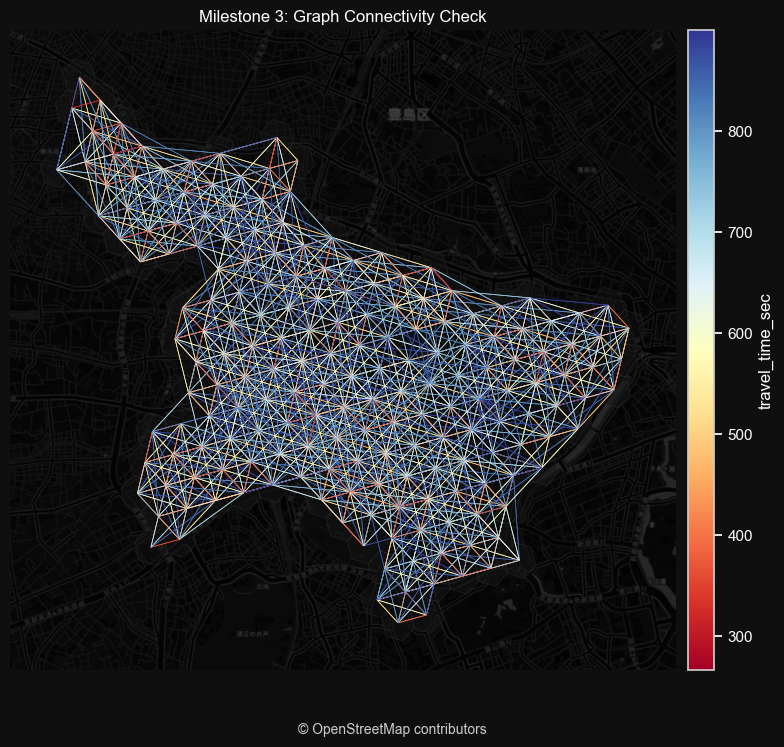

In [13]:
fig, ax = plt.subplots(figsize=(8, 8), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
hex_poly_gdf = hex_gdf.set_geometry("hex_polygon")

hex_poly_gdf.plot(
    ax=ax,
    facecolor=DARK_PANEL,
    edgecolor=DARK_EDGE,
    linewidth=0.6,
    alpha=0.45,
    zorder=1,
 )
add_darkmatter_basemap(ax, hex_poly_gdf.crs)

walk_edges_preview = walk_edges.copy()
edge_values = walk_edges_preview["travel_time_sec"].astype(float)

vmin = edge_values.min()
vmax = edge_values.max()
if np.isclose(vmin, vmax):
    vmax = vmin + 1e-9

edge_norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
edge_cmap = plt.get_cmap(EDGE_CMAP)
edge_colors = [mcolors.to_hex(edge_cmap(edge_norm(value))) for value in edge_values]

divider = make_axes_locatable(ax)
colorbar_ax = divider.append_axes("right", size="4%", pad=0.12)

c2g.plot_graph(
    edges=walk_edges_preview,
    ax=ax,
    bgcolor=DARK_BG,
    edge_color=edge_colors,
    edge_linewidth=0.05 if H3_RESOLUTION>=10 else 0.5,
    edge_alpha=0.5 if H3_RESOLUTION>=10 else 1.0,
    edge_zorder=3,
 )

sm = plt.cm.ScalarMappable(norm=edge_norm, cmap=edge_cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=colorbar_ax)
cbar.set_label("travel_time_sec", color="white")

style_dark_axes(ax, "Milestone 3: Graph Connectivity Check")
colorbar_ax.set_facecolor(DARK_BG)
colorbar_ax.tick_params(colors="white")
colorbar_ax.yaxis.label.set_color("white")
for spine in colorbar_ax.spines.values():
    spine.set_color(ATTRIBUTION_COLOR)

fig.text(0.5, 0.02, "© OpenStreetMap contributors", ha="center", fontsize=10, color=ATTRIBUTION_COLOR)
plt.tight_layout()
plt.show()

## Step 4. Preprocess Features and Convert to PyTorch Geometric

Before training, we standardise the node and edge attributes.

This step:
- Keeps the dominant `landuse` label only for inspection
- Applies `log1p` and standard scaling to POI counts
- Standard-scales land-use occupancy ratios
- Min-max scales edge travel times
- Converts the GeoDataFrames to a homogeneous PyG graph

What to check before moving on:
- `homo_data` prints with the expected number of nodes and edges.
- The scaled feature distributions look centered and numerically stable.

In [14]:
poi_feature_cols = list(poi_counts_by_class.columns)

count_scaler = StandardScaler()
hex_gdf[poi_feature_cols] = count_scaler.fit_transform(
    np.log1p(hex_gdf[poi_feature_cols]).to_numpy(dtype=float)
)

In [15]:
landuse_feature_cols = [
    column for column in hex_gdf.columns
    if isinstance(column, str) and column.startswith("land_use_") and column.endswith("_ratio")
]

if landuse_feature_cols:
    landuse_scaler = StandardScaler()
    hex_gdf[landuse_feature_cols] = landuse_scaler.fit_transform(
        hex_gdf[landuse_feature_cols].astype(float).to_numpy()
    )

In [16]:
all_feature_cols = poi_feature_cols + landuse_feature_cols

edge_scaler = MinMaxScaler()
walk_edges["travel_time_sec"] = edge_scaler.fit_transform(walk_edges[["travel_time_sec"]])

homo_data = c2g.gdf_to_pyg(
    nodes=hex_gdf,
    edges=walk_edges,
    node_feature_cols=all_feature_cols,
    edge_feature_cols=["travel_time_sec"],
)

In [17]:
homo_data

Data(x=[191, 23], edge_index=[2, 3598], edge_attr=[3598, 1], pos=[191, 2], graph_metadata=<city2graph.base.GraphMetadata object at 0x12e14ce10>)

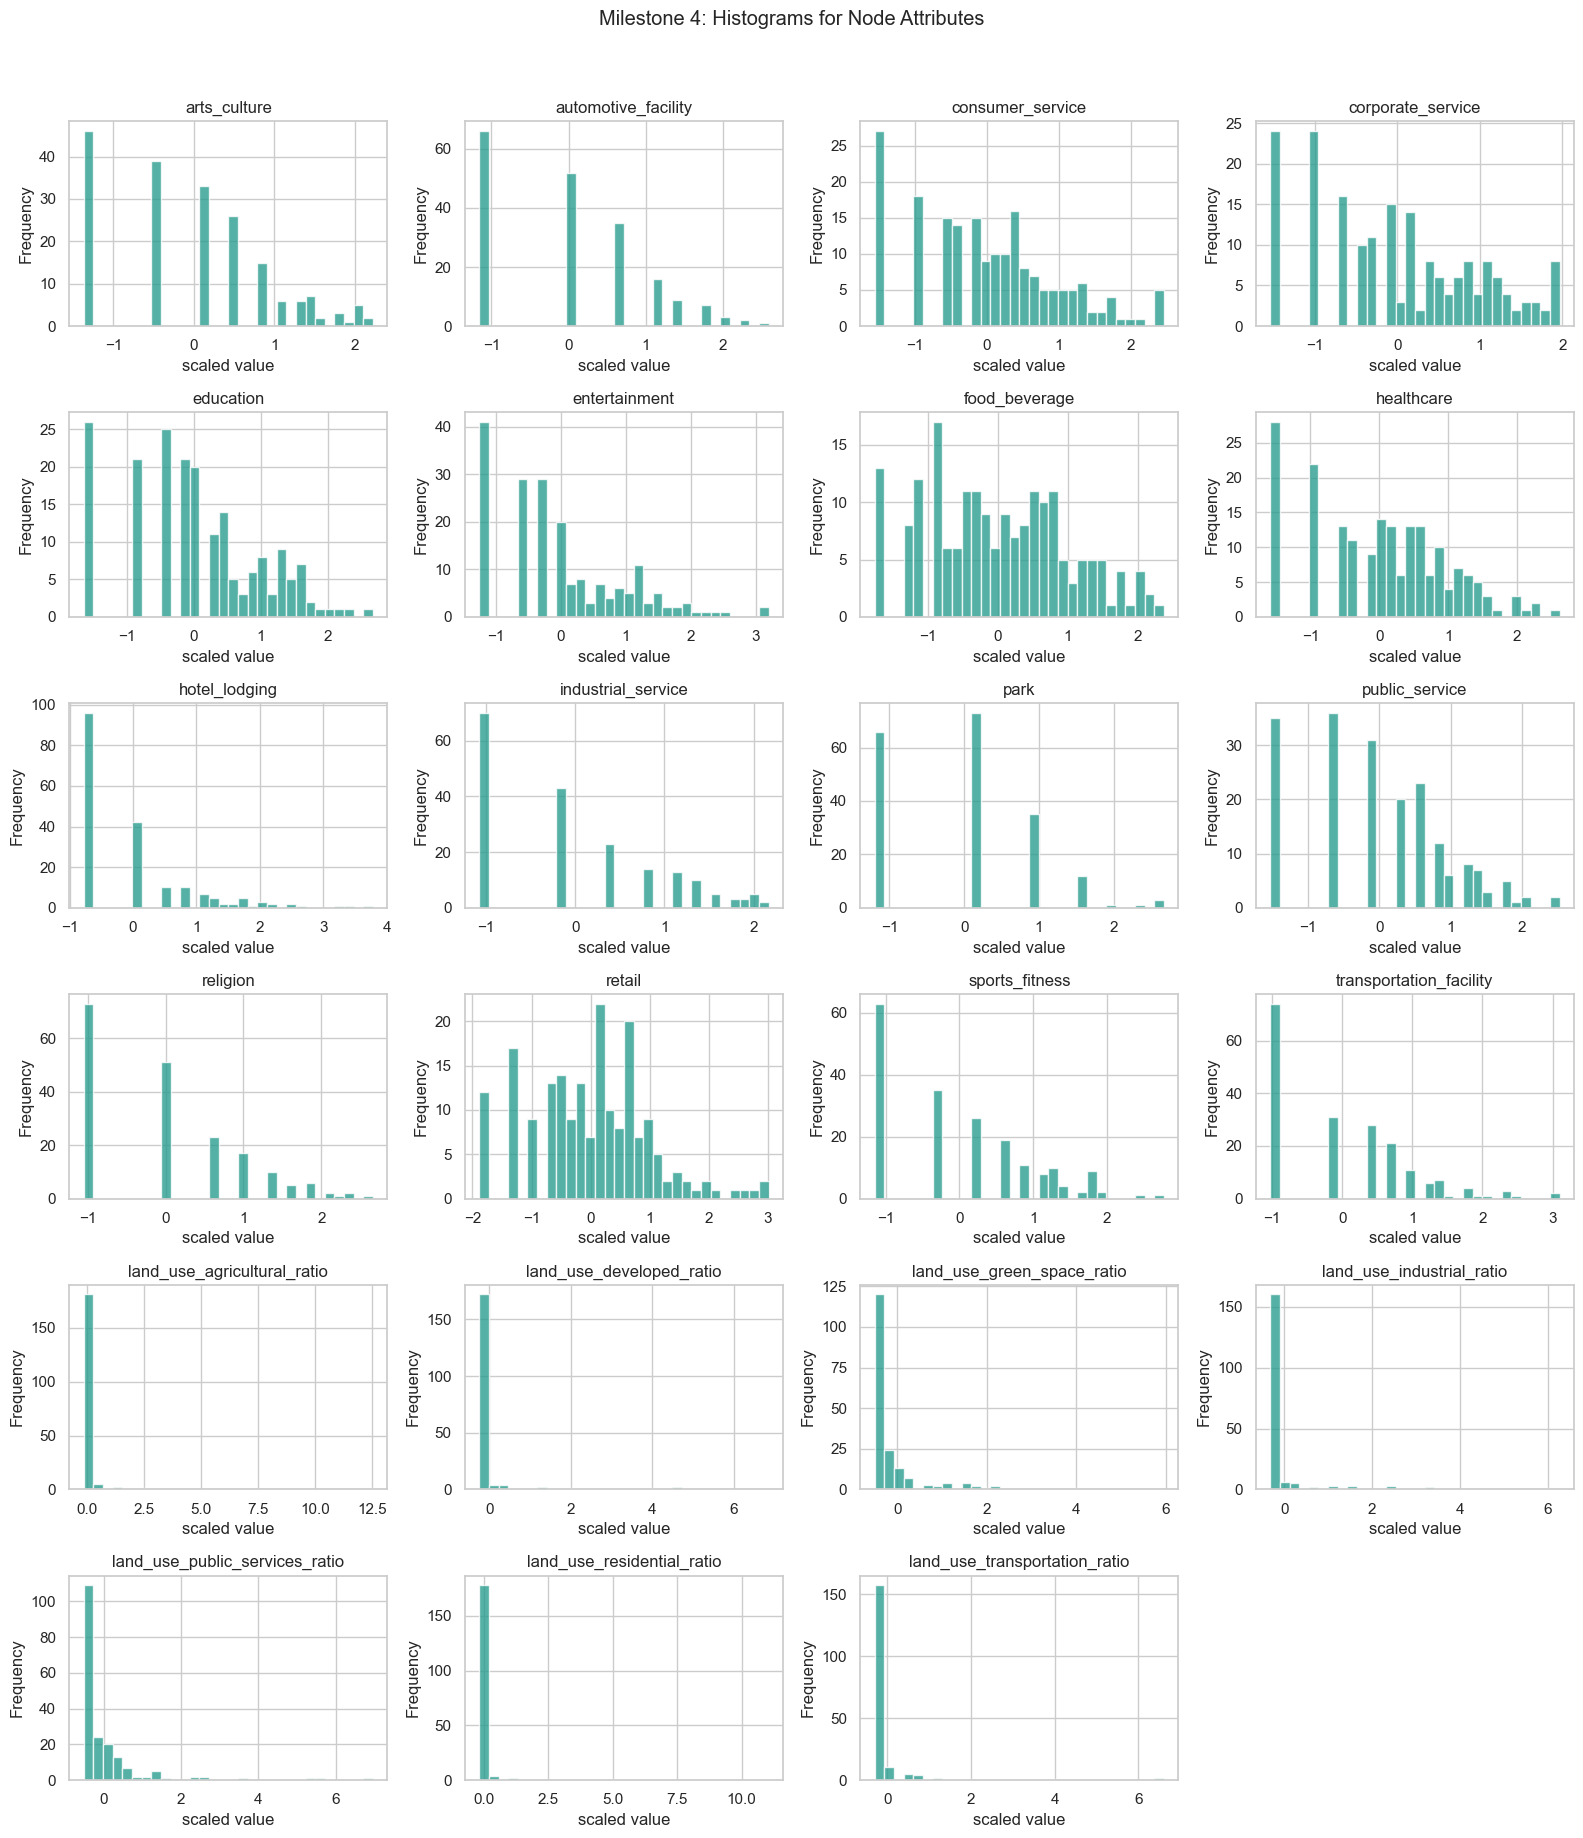

In [18]:
n_cols = 4
n_rows = int(np.ceil(len(all_feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, all_feature_cols):
    ax.hist(hex_gdf[col], bins=30, color="#2a9d8f", alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel("scaled value")
    ax.set_ylabel("Frequency")

for ax in axes[len(all_feature_cols):]:
    ax.axis("off")

fig.suptitle("Milestone 4: Histograms for Node Attributes", y=1.02)
plt.tight_layout()
plt.show()

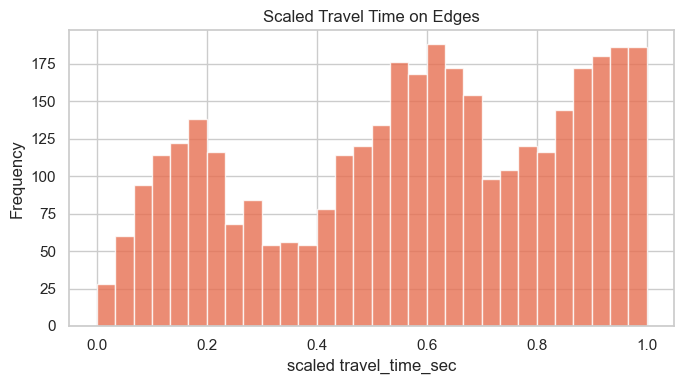

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(walk_edges["travel_time_sec"], bins=30, color="#e76f51", alpha=0.8)
ax.set_title("Scaled Travel Time on Edges")
ax.set_xlabel("scaled travel_time_sec")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Step 5. Train a Graph Autoencoder (GAE)

We now learn a compact embedding for each hexagon. The model uses Graph Attention layers so each node can weigh information from its neighbours.

What to check before moving on:
- The loss generally trends downward over time.
- The final embedding matrix has one row per hexagon.
- Training finishes without running out of memory.

In [20]:
class GATEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6, edge_dim=1):
        super().__init__()
        self.dropout = dropout
        self.conv1 = GATConv(
            in_channels,
            hidden_channels,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=edge_dim,
        )
        self.conv2 = GATConv(
            hidden_channels,
            out_channels,
            heads=1,
            concat=False,
            dropout=dropout,
            edge_dim=edge_dim,
        )

    def forward(self, x, edge_index, edge_attr=None):
        x = self.conv1(x, edge_index, edge_attr=edge_attr).relu()
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index, edge_attr=edge_attr)

In [21]:
in_channels = homo_data.num_node_features
hidden_channels = 16
out_channels = 8
learning_rate = 0.005

model = GAE(GATEncoder(in_channels, hidden_channels, out_channels, edge_dim=1))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

homo_data = homo_data.to(device)
edge_attr = homo_data.edge_attr.view(-1, 1).float()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_history = []

def train_epoch():
    model.train()
    optimizer.zero_grad()
    z = model.encode(homo_data.x, homo_data.edge_index, edge_attr)
    loss = model.recon_loss(z, homo_data.edge_index)
    loss.backward()
    optimizer.step()
    return loss.item()

Epoch: 010, Loss: 1.2416
Epoch: 020, Loss: 1.1993
Epoch: 030, Loss: 1.1896
Epoch: 040, Loss: 1.1246
Epoch: 050, Loss: 1.1014
Epoch: 060, Loss: 1.0792
Epoch: 070, Loss: 1.1111
Epoch: 080, Loss: 1.0256
Epoch: 090, Loss: 1.0631
Epoch: 100, Loss: 0.9984
Epoch: 110, Loss: 1.0146
Epoch: 120, Loss: 1.0179
Epoch: 130, Loss: 0.9801
Epoch: 140, Loss: 0.9633
Epoch: 150, Loss: 0.9835
Epoch: 160, Loss: 1.0102
Epoch: 170, Loss: 0.9716
Epoch: 180, Loss: 0.9689
Epoch: 190, Loss: 0.9701
Epoch: 200, Loss: 0.9876
Epoch: 210, Loss: 0.9704
Epoch: 220, Loss: 0.9688
Epoch: 230, Loss: 0.9580
Epoch: 240, Loss: 0.9572
Epoch: 250, Loss: 0.9155
Epoch: 260, Loss: 0.9716
Epoch: 270, Loss: 1.0015
Epoch: 280, Loss: 0.9391
Epoch: 290, Loss: 0.9792
Epoch: 300, Loss: 0.9652
Epoch: 310, Loss: 0.9522
Epoch: 320, Loss: 0.9812
Epoch: 330, Loss: 0.9224
Epoch: 340, Loss: 0.9369
Epoch: 350, Loss: 0.9579
Epoch: 360, Loss: 0.9497
Epoch: 370, Loss: 0.9506
Epoch: 380, Loss: 0.9258
Epoch: 390, Loss: 0.9271
Epoch: 400, Loss: 0.9504


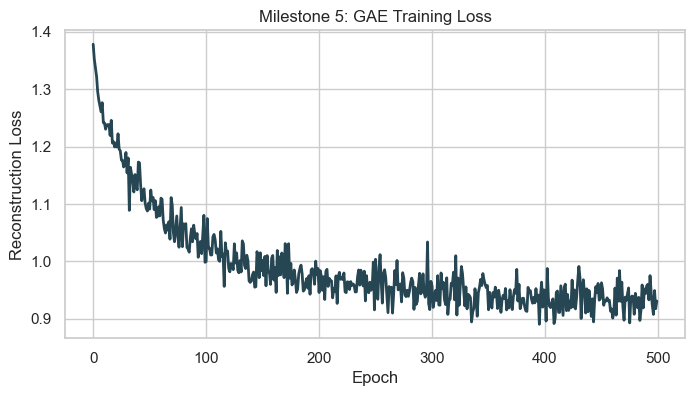

,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7
0,-0.158447,1.098705,-0.285828,-0.495700,-0.192670,-0.685565,0.577451,-0.065563
1,-0.206571,1.161308,-0.027308,-0.623072,-0.199363,-0.771137,0.538517,0.088200
2,-0.240262,1.168531,0.161164,-0.678542,-0.193958,-0.794434,0.508606,0.220617
3,-0.139285,1.096659,-0.102812,-0.598050,-0.128003,-0.700899,0.549483,0.065104
4,-0.147994,1.111813,0.050157,-0.681339,-0.097655,-0.737542,0.536416,0.173204


Milestone 5 complete: embeddings have been learned for every hexagon.


In [22]:
epochs = 500
for epoch in range(1, epochs + 1):
    loss = train_epoch()
    loss_history.append(loss)
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}")

model.eval()
with torch.no_grad():
    z = model.encode(homo_data.x, homo_data.edge_index, edge_attr)

homo_data.embeddings = z.cpu()
emb_cols = [f"embedding_{i}" for i in range(out_channels)]
for i, col in enumerate(emb_cols):
    homo_data[col] = homo_data.embeddings[:, i]

print(f"Learned embeddings shape: {homo_data.embeddings.shape}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color="#264653", linewidth=2)
ax.set_title("Milestone 5: GAE Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Reconstruction Loss")
plt.show()

display(pd.DataFrame(homo_data.embeddings.numpy(), columns=emb_cols).head())
print("Milestone 5 complete: embeddings have been learned for every hexagon.")

## Step 6. Cluster the Learned Embeddings

The embeddings summarise each hexagon's local context and connectivity. We now group similar hexagons into urban clusters.

This notebook runs two clustering methods:
- **HDBSCAN** for variable-shaped clusters with optional noise points
- **K-Means** with the best `k` chosen by silhouette score

What to check before moving on:
- HDBSCAN does not label everything as noise.
- K-Means reports a reasonable best `k`.
- Cluster patterns look spatially coherent rather than random speckle.

In [23]:
homo_data

Data(x=[191, 23], edge_index=[2, 3598], edge_attr=[3598, 1], pos=[191, 2], graph_metadata=<city2graph.base.GraphMetadata object at 0x12e14ce10>, embeddings=[191, 8], embedding_0=[191], embedding_1=[191], embedding_2=[191], embedding_3=[191], embedding_4=[191], embedding_5=[191], embedding_6=[191], embedding_7=[191])

In [24]:
nodes_gdf, _ = c2g.pyg_to_gdf(homo_data, additional_node_cols=emb_cols)

nodes_gdf = nodes_gdf.set_geometry(
    gpd.GeoSeries(hex_gdf["hex_polygon"].values, index=nodes_gdf.index, crs=hex_gdf.crs)
)

Z = nodes_gdf[emb_cols].to_numpy()
Z_norm = normalize(Z, norm="l2")

clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=15)
labels_hdbscan = clusterer.fit_predict(Z_norm)
nodes_gdf["cluster_hdbscan"] = labels_hdbscan
hdbscan_color_map = build_cluster_color_map(labels_hdbscan, noise_label=-1)

In [25]:
best_k = -1
best_score = -1
best_labels_kmeans = None
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init="auto")
    labels = kmeans.fit_predict(Z_norm)
    score = silhouette_score(Z_norm, labels)
    print(f"k={k}: silhouette score = {score:.4f}")
    if score > best_score:
        best_score = score
        best_k = k
        best_labels_kmeans = labels

print(f"Selected K-Means with k={best_k} (score={best_score:.4f})")
nodes_gdf["cluster_kmeans"] = best_labels_kmeans
kmeans_color_map = build_cluster_color_map(best_labels_kmeans)

k=2: silhouette score = 0.2593
k=3: silhouette score = 0.3912
k=4: silhouette score = 0.4719
k=5: silhouette score = 0.5185
k=6: silhouette score = 0.5125
k=7: silhouette score = 0.5048
k=8: silhouette score = 0.5059
k=9: silhouette score = 0.4727
k=10: silhouette score = 0.4604
Selected K-Means with k=5 (score=0.5185)


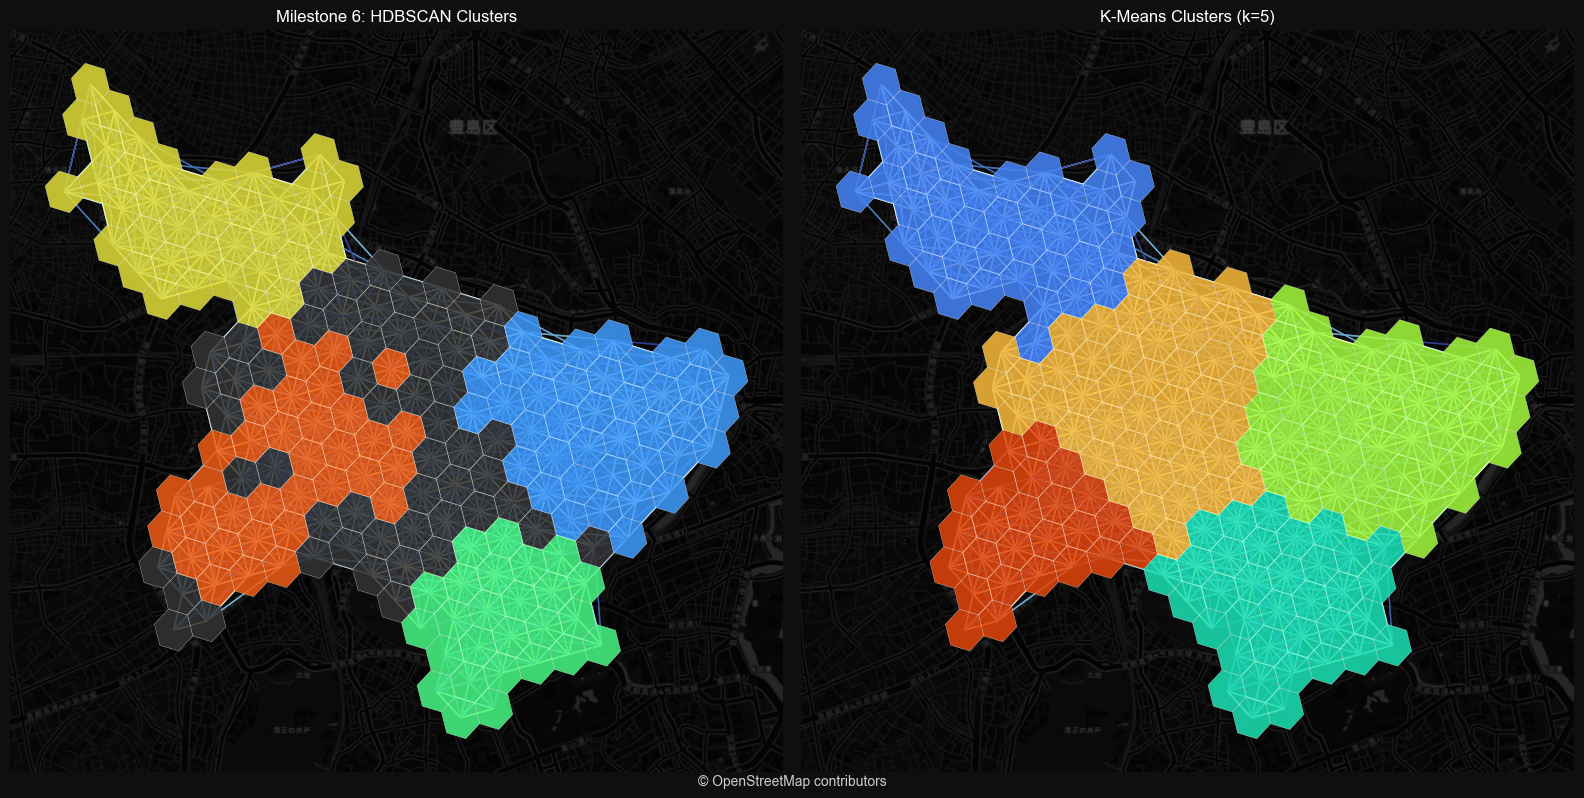

In [26]:
original_travel_time = edge_scaler.inverse_transform(walk_edges[["travel_time_sec"]]).ravel()
walk_edges_plot = walk_edges.assign(travel_time_original=original_travel_time)
norm = mcolors.Normalize(vmin=0, vmax=900)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor=DARK_BG)
plot_specs = [
    (axes[0], "cluster_hdbscan", hdbscan_color_map, "Milestone 6: HDBSCAN Clusters"),
    (axes[1], "cluster_kmeans", kmeans_color_map, f"K-Means Clusters (k={best_k})"),
]

for ax, cluster_col, color_map, title in plot_specs:
    ax.set_facecolor(DARK_BG)
    hex_gdf.set_geometry("hex_polygon").plot(
        ax=ax,
        facecolor=DARK_PANEL,
        edgecolor=DARK_EDGE,
        linewidth=0.6,
        alpha=0.5,
        zorder=1,
    )
    add_darkmatter_basemap(ax, hex_gdf.crs)
    walk_edges_plot.plot(
        ax=ax,
        column="travel_time_original",
        cmap=EDGE_CMAP,
        norm=norm,
        linewidth=1.0,
        alpha=0.9,
        zorder=3,
    )
    nodes_gdf.plot(
        ax=ax,
        color=[color_map[label] for label in nodes_gdf[cluster_col]],
        edgecolor=LIGHT_EDGE,
        linewidth=0.2,
        alpha=0.85,
        zorder=4,
    )
    style_dark_axes(ax, title)

fig.text(0.5, 0.02, "© OpenStreetMap contributors", ha="center", fontsize=10, color=ATTRIBUTION_COLOR)
plt.tight_layout()
fig.savefig(CLUSTERING_RESULT_PATH, dpi=300, facecolor=DARK_BG, bbox_inches="tight")
plt.show()

In [27]:
hdbscan_counts = pd.Series(nodes_gdf["cluster_hdbscan"]).value_counts().sort_index()
kmeans_counts = pd.Series(nodes_gdf["cluster_kmeans"]).value_counts().sort_index()
display(pd.DataFrame({"hdbscan_count": hdbscan_counts}))
display(pd.DataFrame({"kmeans_count": kmeans_counts}))

,hdbscan_count
cluster_hdbscan,
-1,54
0,39
1,26
2,38
3,34


,kmeans_count
cluster_kmeans,
0,40
1,35
2,45
3,46
4,25


## Step 7. Export an Interactive Web Map

The final step packages the clustering result into a shareable HTML map. You can keep both HDBSCAN and K-Means as switchable layers.

What to check before finishing:
- The HTML file is written to `data/interactive_map.html`.
- The embedded preview opens below the cell.
- The layer control lets you toggle cluster layers.

In [ ]:
m_nodes = nodes_gdf.to_crs(epsg=4326)

bounds = m_nodes.total_bounds
center_lat_lon = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
m = folium.Map(location=center_lat_lon, zoom_start=15, tiles="CartoDB dark_matter")

m_nodes_hdbscan = m_nodes[["cluster_hdbscan", "geometry"]].copy().reset_index()
m_nodes_hdbscan["cluster_color"] = m_nodes_hdbscan["cluster_hdbscan"].map(hdbscan_color_map)
hdbscan_layer = folium.FeatureGroup(name="HDBSCAN Clusters")
folium.GeoJson(
    data=m_nodes_hdbscan[["h3_index", "cluster_hdbscan", "cluster_color", "geometry"]].to_json(),
    style_function=lambda feature: {
        "fillColor": feature["properties"]["cluster_color"],
        "color": feature["properties"]["cluster_color"],
        "weight": 1,
        "fillOpacity": 0.45,
    },
    tooltip=folium.GeoJsonTooltip(fields=["h3_index", "cluster_hdbscan"]),
).add_to(hdbscan_layer)
hdbscan_layer.add_to(m)

m_nodes_kmeans = m_nodes[["cluster_kmeans", "geometry"]].copy().reset_index()
m_nodes_kmeans["cluster_color"] = m_nodes_kmeans["cluster_kmeans"].map(kmeans_color_map)
kmeans_layer = folium.FeatureGroup(name="K-Means Clusters", show=False)
folium.GeoJson(
    data=m_nodes_kmeans[["h3_index", "cluster_kmeans", "cluster_color", "geometry"]].to_json(),
    style_function=lambda feature: {
        "fillColor": feature["properties"]["cluster_color"],
        "color": feature["properties"]["cluster_color"],
        "weight": 1,
        "fillOpacity": 0.45,
    },
    tooltip=folium.GeoJsonTooltip(fields=["h3_index", "cluster_kmeans"]),
).add_to(kmeans_layer)
kmeans_layer.add_to(m)

folium.LayerControl().add_to(m)
m.save(INTERACTIVE_MAP_PATH)
print(f"Saved interactive map to '{INTERACTIVE_MAP_PATH}'")